# Geocalibration

Here we use the geocalibration data calculated from agisoft metashape using the OPK values. The fitting will be done for each focus positions and camera. We will use the $R^r_{r'}$ values fitted from the 034 and fit $R^m_{c,0}$ and $R^m_{c,1}$ for each left and right camera between focus positions 026-110.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import json
import itertools
import plotly.express as px
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize

from typing import List

In [3]:
data_fpath = "../plots/m41_site_cal_v230_v3_20240809_165619.xlsx"
f_str = "034"

to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_mat = lambda x:np.array([[float(val.strip()) for val in r[1:].split(", ") if len(val)] for r in x[1:-2].split("], ")])

def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_comma)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_comma)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_comma)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_comma)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

  return z_data

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
    """
    Form the H matrix from the ground truth data
    """
    h_r = data_["h_r_vec"][idx]
    v_r = data_["v_r_vec"][idx]
    a_r = data_["a_r_vec"][idx]

    H_r = np.array([h_r, v_r, a_r]).T

    return H_r

# read in the data
data_all = pd.read_excel(data_fpath, index_col=0)
data_all = parse_cahvor(data_all)


In [38]:
data_all["cam"].unique()

array(['ZR063', 'ZR110', 'ZL110', 'ZL063', 'ZR048', 'ZR079', 'ZL048',
       'ZL079', 'ZR034', 'ZL034', 'ZR026', 'ZL026'], dtype=object)

In [40]:
f_str = "079"

zl_f = data_all[data_all["cam"]==f"ZL{f_str}"].copy().reset_index()
zr_f = data_all[data_all["cam"]==f"ZR{f_str}"].copy().reset_index()

fig = px.scatter(zl_f, x="fmc", y="f_est", hover_data="index", title=f"ZL{f_str}")
# fig.show()


fig = px.scatter(zr_f, x="fmc", y="f_est", hover_data="index", title=f"ZR{f_str}")
# fig.show()

In [41]:
set(['063', '110', '110', '063', '048', '079', '048', '079', '034', '034', '026', '026'])


{'026', '034', '048', '063', '079', '110'}

In [33]:
# read in the data
data_all = pd.read_excel(data_fpath, index_col=0)
data_all = parse_cahvor(data_all)

# drop the outliers
drop_idxs = [1298, 1434, 1861, 1886, 1887, 1889, 1894, 1896, 1898, 1910, 1911, 1912, 1926, 1927, 1928] # outliers based on fl-fmc plots
data_all.drop(axis=0, index=drop_idxs, inplace=True)
data_all.reset_index(inplace=True, drop=True)

# split into left and right camera
zl34, zr34 = get_zl_zr(f_str, data_all)

# data structure to store the fits
f_strs = ['026', '034', '048', '063', '079', '110']
template = {"fl0":None, "fl1":None, 
          "rot_mc_0":None, "rot_mc_1":None,
          "lmbd_h":0.3, "lmbd_v":0.009, "lmbd_a":90}
params = {f"ZL{f_str}":template.copy()}
params.update({f"ZR{f_str}":template.copy()})
params["rot_rrp"] = R.from_quat([0,0,0,1])

# Focal Length Fits

In [3]:
X_l, Y_l = np.vstack([np.ones(zl34.shape[0]), zl34["fmc"]]).T , zl34["f_est"]
theta_l = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ Y_l
params["ZL034"]["fl0"], params["ZL034"]["fl1"] = theta_l
print(f"[L] fl = {theta_l[0]:.5f} + {theta_l[1]:.5f} * fmc")

X_r, Y_r = np.vstack([np.ones(zr34.shape[0]), zr34["fmc"]]).T , zr34["f_est"]
theta_r = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ Y_r
params["ZR034"]["fl0"], params["ZR034"]["fl1"] = theta_r
print(f"[R] fl = {theta_r[0]:.5f} + {theta_r[1]:.5f} * fmc")

[L] fl = 4687.11755 + 0.04762 * fmc
[R] fl = 4694.16181 + 0.04853 * fmc


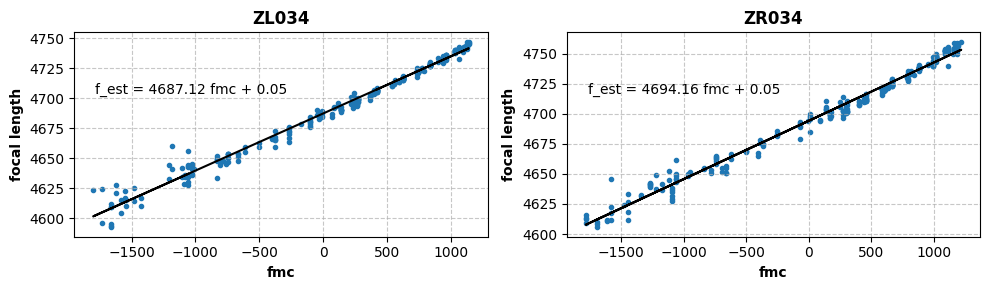

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
f_str = "034"

# ZL034 FL-FMC plots
ax[0].scatter(zl34["fmc"], zl34["f_est"], marker='.')
ax[0].plot(zl34["fmc"], [theta_l[0] + theta_l[1] * f for f in zl34["fmc"]],
        color="black")
ax[0].grid(linestyle="--", alpha=0.7)
ax[0].set_xlabel("fmc", fontweight="bold")
ax[0].set_ylabel("focal length", fontweight="bold")
ax[0].set_title(f"ZL034", fontweight="bold")
ax[0].text(0.05, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_l), transform=ax[0].transAxes)


# ZR034 FL-FMC plots
ax[1].scatter(zr34["fmc"], zr34["f_est"], marker='.')
ax[1].plot(zr34["fmc"], [theta_r[0] + theta_r[1] * f for f in zr34["fmc"]],
        color="black")
ax[1].grid(linestyle="--", alpha=0.7)
ax[1].set_xlabel("fmc", fontweight="bold")
ax[1].set_ylabel("focal length", fontweight="bold")
ax[1].set_title(f"ZR034", fontweight="bold")
ax[1].text(0.05, 0.7, "f_est = {:.2f} fmc + {:.2f}".format(*theta_r), transform=ax[1].transAxes)

fig.tight_layout()

# Rotation Fitting

### Kabsch Fit

In [5]:

def solve_r_mc(data_, params_):
    data_ = data_.copy()
    params_ = params_.copy()
    R_rrp = params_["rot_rrp"].as_matrix()

    for f_str in f_strs:
        zl, zr = get_zl_zr(f_str, data_)

        # LEFT CAMERA FITS
        m_frame_l, c_frame_l = [], []
        for i in range(zl.shape[0]):
            # compute hm from hr
            Hr = get_H_r_data(i, zl)
            R_rpm = get_R_rpm(i, zl)
            Hm = (R_rrp @ R_rpm).T @ Hr
            m_frame_l.append(params[f"ZL{f_str}"]["lmbd_h"] * Hm[:, 0])
            m_frame_l.append(params[f"ZL{f_str}"]["lmbd_v"] * Hm[:, 1])
            m_frame_l.append(params[f"ZL{f_str}"]["lmbd_a"] * Hm[:, 2])

            # compute hc
            f, b1, b2, cx, cy = zl[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i, :]
            fl = params_[f"ZL{f_str}"]["fl0"] + params_[f"ZL{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            c_frame_l.append(params[f"ZL{f_str}"]["lmbd_h"] * Hc[:, 0])
            c_frame_l.append(params[f"ZL{f_str}"]["lmbd_v"] * Hc[:, 1])
            c_frame_l.append(params[f"ZL{f_str}"]["lmbd_a"] * Hc[:, 2])

        params_[f"ZL{f_str}"]["rot_mc_0"], _ = R.align_vectors(m_frame_l, c_frame_l, return_sensitivity=False)

        # RIGHT CAMERA FITS
        m_frame_r, c_frame_r = [], []
        for i in range(zr.shape[0]):
            # compute hm from hr
            Hr = get_H_r_data(i, zr)
            R_rpm = get_R_rpm(i, zr)
            Hm = (R_rrp @ R_rpm).T @ Hr
            m_frame_r.append(params[f"ZR{f_str}"]["lmbd_h"] * Hm[:, 0])
            m_frame_r.append(params[f"ZR{f_str}"]["lmbd_v"] * Hm[:, 1])
            m_frame_r.append(params[f"ZR{f_str}"]["lmbd_a"] * Hm[:, 2])

            # compute hc
            f, b1, b2, cx, cy = zr[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i, :]
            fl = params_[f"ZR{f_str}"]["fl0"] + params_[f"ZR{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            c_frame_r.append(params[f"ZR{f_str}"]["lmbd_h"] * Hc[:, 0])
            c_frame_r.append(params[f"ZR{f_str}"]["lmbd_v"] * Hc[:, 1])
            c_frame_r.append(params[f"ZR{f_str}"]["lmbd_a"] * Hc[:, 2])

        params_[f"ZR{f_str}"]["rot_mc_0"], _ = R.align_vectors(m_frame_r, c_frame_r, return_sensitivity=False)
    
    return params_

def solve_r_rrp(data_, params_):
    data_ = data_.copy()
    params_ = params_.copy()
    # solve for rrp
    r_frame, rp_frame = [], []

    for f_str in f_strs:
        zl, zr = get_zl_zr(f_str, data_all)

        # left camera
        R_mc_l = params_[f"ZL{f_str}"]["rot_mc_0"].as_matrix()
        for i in range(zl.shape[0]):
            # r frame vectors
            Hr = get_H_r_data(i, zl)
            r_frame.append(params_[f"ZL{f_str}"]["lmbd_h"] * Hr[:, 0])
            r_frame.append(params_[f"ZL{f_str}"]["lmbd_v"] * Hr[:, 1])
            r_frame.append(params_[f"ZL{f_str}"]["lmbd_a"] * Hr[:, 2])

            # r' frame vectors
            R_rpm = get_R_rpm(i, zl)
            f, b1, b2, cx, cy = zl[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
            fl = params_[f"ZL{f_str}"]["fl0"] + params_[f"ZL{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            Hrp = R_rpm @ R_mc_l @ Hc
            rp_frame.append(params_[f"ZL{f_str}"]["lmbd_h"] * Hrp[:, 0])
            rp_frame.append(params_[f"ZL{f_str}"]["lmbd_v"] * Hrp[:, 1])
            rp_frame.append(params_[f"ZL{f_str}"]["lmbd_a"] * Hrp[:, 2])

        # right camera
        R_mc_r = params_[f"ZR{f_str}"]["rot_mc_0"].as_matrix()
        for i in range(zr.shape[0]):
            # r frame vectors
            Hr = get_H_r_data(i, zr)
            r_frame.append(params_[f"ZR{f_str}"]["lmbd_h"] * Hr[:, 0])
            r_frame.append(params_[f"ZR{f_str}"]["lmbd_v"] * Hr[:, 1])
            r_frame.append(params_[f"ZR{f_str}"]["lmbd_a"] * Hr[:, 2])

            # r' frame vectors
            R_rpm = get_R_rpm(i, zr)
            f, b1, b2, cx, cy = zr[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
            fl = params_[f"ZR{f_str}"]["fl0"] + params_[f"ZR{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            Hrp = R_rpm @ R_mc_l @ Hc
            rp_frame.append(params_[f"ZR{f_str}"]["lmbd_h"] * Hrp[:, 0])
            rp_frame.append(params_[f"ZR{f_str}"]["lmbd_v"] * Hrp[:, 1])
            rp_frame.append(params_[f"ZR{f_str}"]["lmbd_a"] * Hrp[:, 2])

    params_["rot_rrp"], _ = R.align_vectors(r_frame, rp_frame, return_sensitivity=False)
    return params_

def calc_total_rel_error(data_, params_):
    # compute the relative error
    data_ = data_.copy()
    params_ = params_.copy()

    R_rrp = params["rot_rrp"].as_matrix()
    tot_rel_err = 0
    for f_str in f_strs:
        zl, zr = get_zl_zr(f_str, data_)

        # left camera errors
        R_mc_l = params_[f"ZL{f_str}"]["rot_mc_0"].as_matrix()
        for i in range(zl.shape[0]):
            Hr_data = get_H_r_data(i, zl)

            R_rpm = get_R_rpm(i, zl)
            f, b1, b2, cx, cy = zl[["fmc", "b1", "b2", "cx", "cy"]].iloc[i, :]
            fl = params_[f"ZL{f_str}"]["fl0"] + params_[f"ZL{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            Hr_model = R_rrp @ R_rpm @ R_mc_l @ Hc

            tot_rel_err = np.linalg.norm(Hr_data[:, 0] - Hr_model[:, 0])/np.linalg.norm(Hr_data[:, 0])
            tot_rel_err = np.linalg.norm(Hr_data[:, 1] - Hr_model[:, 1])/np.linalg.norm(Hr_data[:, 1])
            tot_rel_err = np.linalg.norm(Hr_data[:, 2] - Hr_model[:, 2])/np.linalg.norm(Hr_data[:, 2])


        # right camera errors
        R_mc_r = params_[f"ZR{f_str}"]["rot_mc_0"].as_matrix()
        for i in range(zr.shape[0]):
            Hr_data = get_H_r_data(i, zr)

            R_rpm = get_R_rpm(i, zr)
            f, b1, b2, cx, cy = zr[["fmc", "b1", "b2", "cx", "cy"]].iloc[i, :]
            fl = params_[f"ZR{f_str}"]["fl0"] + params_[f"ZR{f_str}"]["fl1"] * f
            Hc = np.array([[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]])
            Hr_model = R_rrp @ R_rpm @ R_mc_r @ Hc

            tot_rel_err = np.linalg.norm(Hr_data[:, 0] - Hr_model[:, 0])/np.linalg.norm(Hr_data[:, 0])
            tot_rel_err = np.linalg.norm(Hr_data[:, 1] - Hr_model[:, 1])/np.linalg.norm(Hr_data[:, 1])
            tot_rel_err = np.linalg.norm(Hr_data[:, 2] - Hr_model[:, 2])/np.linalg.norm(Hr_data[:, 2])
    
    return tot_rel_err

def kabsch_fit(data_, params_, verbosity=False, niters=250, verbose=25, eps=1e-6):
    data_ = data_.copy()
    params_ = params_.copy()

    total_rel_err = 0
    for i in range(niters):
        params_ = solve_r_mc(data_, params_)
        params_ = solve_r_rrp(data_, params_)
        total_rel_err_new = calc_total_rel_error(data_, params)

        # if change in relative error is small, break the loop
        if abs(total_rel_err - total_rel_err_new) < eps:
            if verbosity:
                print(f"Iteration {i}")
                print(f"Total Relative Error: {total_rel_err:.8f}")
                for f_str in f_strs:
                    print(f"[ZL{f_str}] q_mc: {params_[f'ZL{f_str}']['rot_mc_0'].as_quat(canonical=True)}")
                    print(f"[ZR{f_str}] q_mc: {params_[f'ZR{f_str}']['rot_mc_0'].as_quat(canonical=True)}")
                print(f"q_rrp: {params_['rot_rrp'].as_quat(canonical=True)}")
            break
        total_rel_err = total_rel_err_new

        # print for verbosity
        if verbosity and ((i%verbose == 0 and i>0) or (i == niters-1)):
            print(f"Iteration {i}")
            print(f"Total Relative Error: {total_rel_err:.8f}")
            for f_str in f_strs:
                print(f"[ZL{f_str}] q_mc: {params_[f'ZL{f_str}']['rot_mc_0'].as_quat(canonical=True)}")
                print(f"[ZR{f_str}] q_mc: {params_[f'ZR{f_str}']['rot_mc_0'].as_quat(canonical=True)}")
            print(f"q_rrp: {params_['rot_rrp'].as_quat(canonical=True)}")
            print("="*150)

    return params_


We first perform a hyperparameter tuning to find $\lambda_h$, $\lambda_v$ & $\lambda_a$ such that when Kabsch algorithm is runned on the sets $\{\lambda_h h^r_i, \lambda_v v^r_i, \lambda_a a^r_i\}$ and $\{\lambda_h h^c_i, \lambda_v v^c_i, \lambda_a a^c_i\}$, the sum of the relative errors for the $h$, $v$ and $a$ vectors are minimized.

In [ ]:
# search space 
lambda_hs = [0.003, 0.009, 0.03, 0.09, 0.3, 0.9]
lambda_vs = [0.003, 0.009, 0.03, 0.09, 0.3, 0.9]
lambda_as = [0.3, 0.9, 3, 9, 30, 90]


params_temp = params.copy()

errs = []
# for lmbd_h_l, lmbd_v_l, lmbd_a_l, lmbd_h_r, lmbd_v_r, lmbd_a_r in tqdm(itertools.product(lambda_hs, lambda_vs, lambda_as, lambda_hs, lambda_vs, lambda_as)):
#       params_temp["ZL034"]["lmbd_h"], params_temp["ZL034"]["lmbd_v"], params_temp["ZL034"]["lmbd_a"] = lmbd_h_l, lmbd_v_l, lmbd_a_l
#       params_temp["ZR034"]["lmbd_h"], params_temp["ZR034"]["lmbd_v"], params_temp["ZR034"]["lmbd_a"] = lmbd_h_r, lmbd_v_r, lmbd_a_r

#       params_temp = kabsch_fit(data_all, params_temp, niters=50)
#       rel_err = calc_total_rel_error(data_all, params_temp)
#       errs.append((lmbd_h_l, lmbd_v_l, lmbd_a_l, lmbd_h_r, lmbd_v_r, lmbd_a_r, rel_err))


In [7]:
# find the set of lambda that has the smallest relative error from kabsch fit
sorted_errs = sorted(errs, key=lambda x:x[6])
best_lmbd_h_l, best_lmbd_v_l, best_lmbd_a_l, best_lmbd_h_r, best_lmbd_v_r, best_lmbd_a_r, best_rel_err = sorted_errs[0]
print(f"Relative error: {best_rel_err:.5f}")
print(f"[ZL] lmbd_h:{best_lmbd_h_l}, lmbd_v:{best_lmbd_v_l}, lmbd_a:{best_lmbd_a_l}")     
print(f"[ZR] lmbd_h:{best_lmbd_h_r}, lmbd_v:{best_lmbd_v_r}, lmbd_a:{best_lmbd_a_r}")

Relative error: 0.00574
[ZL] lmbd_h:0.003, lmbd_v:0.003, lmbd_a:90
[ZR] lmbd_h:0.003, lmbd_v:0.009, lmbd_a:9


In [9]:
# perform kabsch fit using best set of lambdas 
params["ZL034"]["lmbd_h"], params["ZL034"]["lmbd_v"], params["ZL034"]["lmbd_a"] = 0.03, 0.003, 90
params["ZR034"]["lmbd_h"], params["ZR034"]["lmbd_v"], params["ZR034"]["lmbd_a"] = 0.03, 0.003, 90

params = kabsch_fit(data_all, params, verbosity=True, niters=500, verbose=100, eps=1e-9)

Iteration 100
Total Relative Error: 0.03638804
[ZL034] q_mc: [0.48137173 0.5110718  0.5540357  0.44736038]
[ZR034] q_mc: [0.49472888 0.49806406 0.54600495 0.45722437]
q_rrp: [ 1.96945276e-03 -9.80370401e-05 -7.48646249e-02  9.97191757e-01]
Iteration 124
Total Relative Error: 0.03638817
[ZL034] q_mc: [0.48137172 0.51107181 0.55403575 0.44736032]
[ZR034] q_mc: [0.49472887 0.49806407 0.546005   0.45722431]
q_rrp: [ 1.96945500e-03 -9.80360379e-05 -7.48646990e-02  9.97191751e-01]


Text(0.5, 0.98, '$H^r$ for ZL034 Iterative Kabsch Fit')

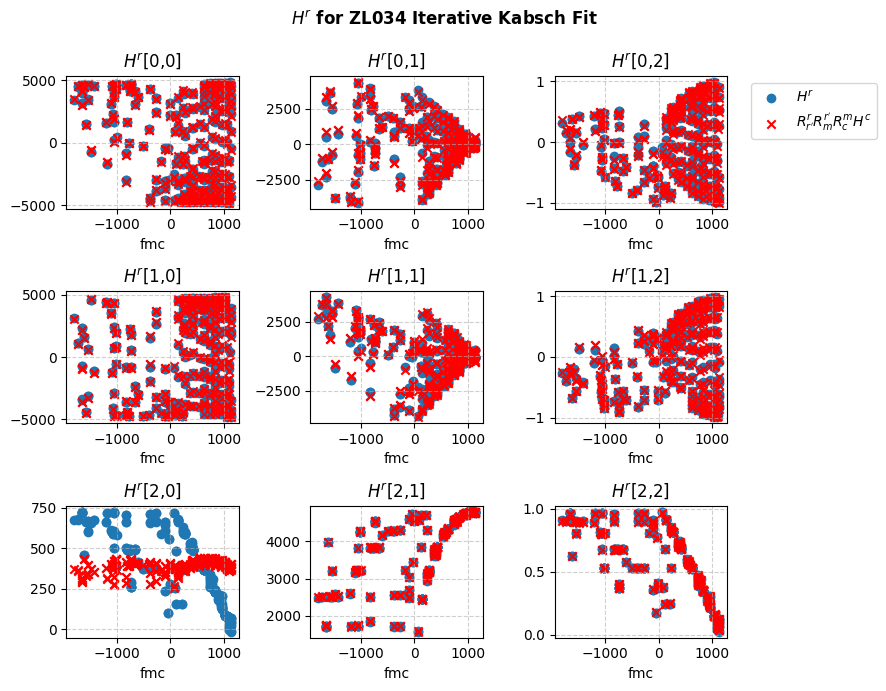

In [10]:
def plot_hr(data_, rot_rrp, rot_mc, fl0, fl1):
  hr_data_left, hr_model_left = [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle(f"$H^r$ plot", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

fig, ax = plot_hr(zl34, rot_rrp=params["rot_rrp"], rot_mc=params["ZL034"]["rot_mc_0"],
              fl0=params["ZL034"]["fl0"], fl1=params["ZL034"]["fl1"])
fig.suptitle("$H^r$ for ZL034 Iterative Kabsch Fit", fontweight="bold", fontsize=12)

Text(0.5, 0.98, '$H^r$ for ZL034 Iterative Kabsch Fit')

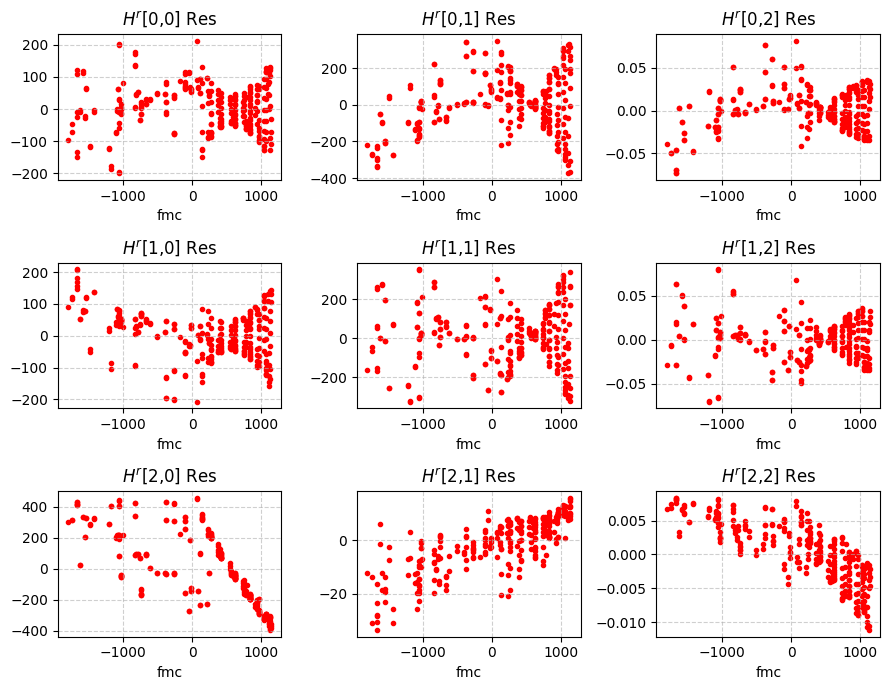

In [11]:
def plot_hr_res(data_, rot_rrp, rot_mc, fl0, fl1):
  hr_res = []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr = get_H_r_data(i, data_)

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    
    # compute res
    hr_res.append(Hr - R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_res],
                      marker='.', color='red')
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}] Res")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.tight_layout()

  return fig, ax

plot_hr_res(zl34, rot_rrp=params["rot_rrp"], rot_mc=params["ZL034"]["rot_mc_0"],
              fl0=params["ZL034"]["fl0"], fl1=params["ZL034"]["fl1"])
fig.suptitle("$H^r$ for ZL034 Iterative Kabsch Fit", fontweight="bold", fontsize=12)

Next, we use the rotations that were found by the iterative kabsch algorithm as an initial guess for BFGS fits. 

In [12]:

def obj(x:List):
    R_rrp = R.from_quat(x[:4]).as_matrix()
    rot_mc_l_0 = R.from_quat(x[4:8])
    rot_mc_l_1 = R.from_quat(x[8:12])
    rot_mc_r_0 = R.from_quat(x[12:16])
    rot_mc_r_1 = R.from_quat(x[16:20])
    
    zl, zr = get_zl_zr("034", data_all)

    total_cost = 0

    # left camera
    for i in range(zl.shape[0]):
        # H^r matrix
        Hr = get_H_r_data(i, zl)

        # H^c matrix
        f, b1, b2, cx, cy = zl[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
        cam = zl["cam"].iloc[i]
        fl = params["ZL034"]["fl0"] + params["ZL034"]["fl1"] * f
        Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]

        # rotation matrices
        R_rpm = get_R_rpm(i, zl)
        R_mc = (rot_mc_l_0 * (rot_mc_l_1**(f/1000))).as_matrix()

        # Errors
        err = (Hr - R_rrp @ R_rpm @ R_mc @ Hc)
        total_cost += np.linalg.norm(err[:,0])**2 / np.linalg.norm(Hr[:,0])**2
        total_cost += np.linalg.norm(err[:,1])**2 / np.linalg.norm(Hr[:,1])**2
        total_cost += np.linalg.norm(err[:,2])**2 / np.linalg.norm(Hr[:,2])**2

    # right camera
    for i in range(zr.shape[0]):
        # H^r matrix
        Hr = get_H_r_data(i, zr)

        # H^c matrix
        f, b1, b2, cx, cy = zr[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
        cam = zr["cam"].iloc[i]
        fl = params["ZR034"]["fl0"] + params["ZR034"]["fl1"] * f
        Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]

        # rotation matrices
        R_rpm = get_R_rpm(i, zr)
        R_mc = (rot_mc_r_0 * (rot_mc_r_1**(f/1000))).as_matrix()

        # Errors
        err = (Hr - R_rrp @ R_rpm @ R_mc @ Hc)
        total_cost += np.linalg.norm(err[:,0])**2 / np.linalg.norm(Hr[:,0])**2
        total_cost += np.linalg.norm(err[:,1])**2 / np.linalg.norm(Hr[:,1])**2
        total_cost += np.linalg.norm(err[:,2])**2 / np.linalg.norm(Hr[:,2])**2

    return total_cost

q_rrp = list(params["rot_rrp"].as_quat(canonical=True))
q_mc0_l = list(params["ZL034"]["rot_mc_0"].as_quat(canonical=True))
q_mc0_r = list(params["ZR034"]["rot_mc_0"].as_quat(canonical=True))
x0 = q_rrp + q_mc0_l + [0,0,0,1] + q_mc0_r + [0,0,0,1]

res = minimize(obj, x0, method="BFGS",
                      options={"gtol":1e-6, "xrtol":1e-6, "maxiter":5000})

q_rrp = np.array(res.x[:4])/np.linalg.norm(res.x[:4])
q_mc_zl_0 = np.array(res.x[4:8])/np.linalg.norm(res.x[4:8])
q_mc_zl_1 = np.array(res.x[8:12])
q_mc_zr_0 = np.array(res.x[12:16])/np.linalg.norm(res.x[12:16])
q_mc_zr_1 = np.array(res.x[16:20])

print(f"Final function value:\t{res.fun:.6f}")
print(f"Final Jacobian value:\t{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:\t\t{q_rrp}")
print(f"q_mc_zl_0:\t{list(q_mc_zl_0)}")
print(f"q_mc_zl_1:\t{list(q_mc_zl_1)}")
print(f"q_mc_zr_0:\t{list(q_mc_zr_0)}")
print(f"q_mc_zr_1:\t{list(q_mc_zr_1)}")
print("="*150)

Final function value:	0.002294
Final Jacobian value:	0.001463
q_rrp:		[-6.34364184e-05 -1.97517724e-05  7.48470640e-04  9.99999718e-01]
q_mc_zl_0:	[0.49121763735979374, 0.5048453961637196, 0.5059386051201764, 0.49785789796688895]
q_mc_zl_1:	[8.931508281459497e-05, -6.518318631597788e-05, -4.7543658165853376e-05, 0.7765005835154448]
q_mc_zr_0:	[0.5047444951619646, 0.4893180870327238, 0.49778290281951876, 0.5079497868558495]
q_mc_zr_1:	[0.0001231555408274842, -0.00013366758848362651, -4.241620725103658e-05, 0.9288740349525433]


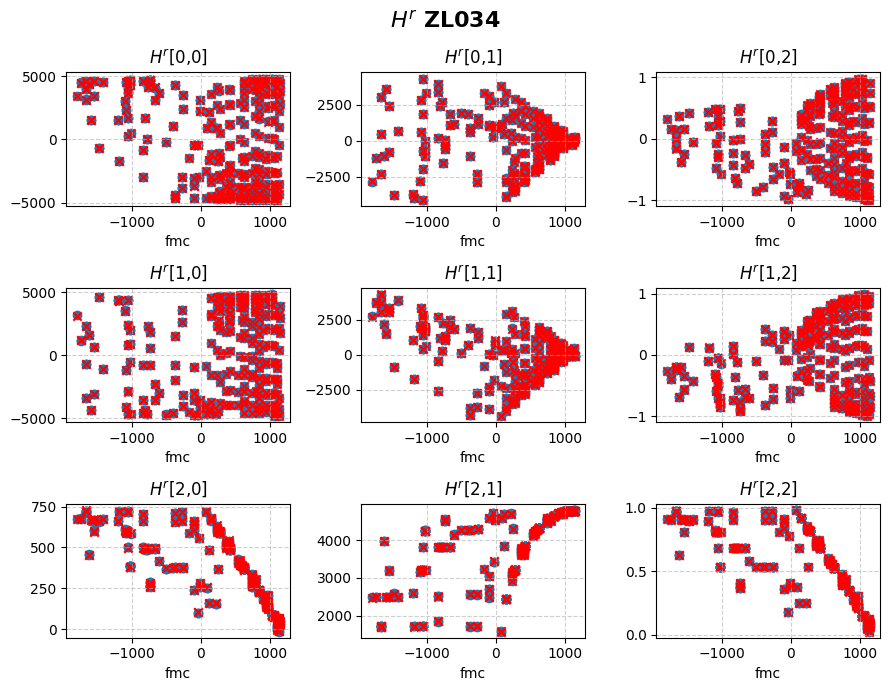

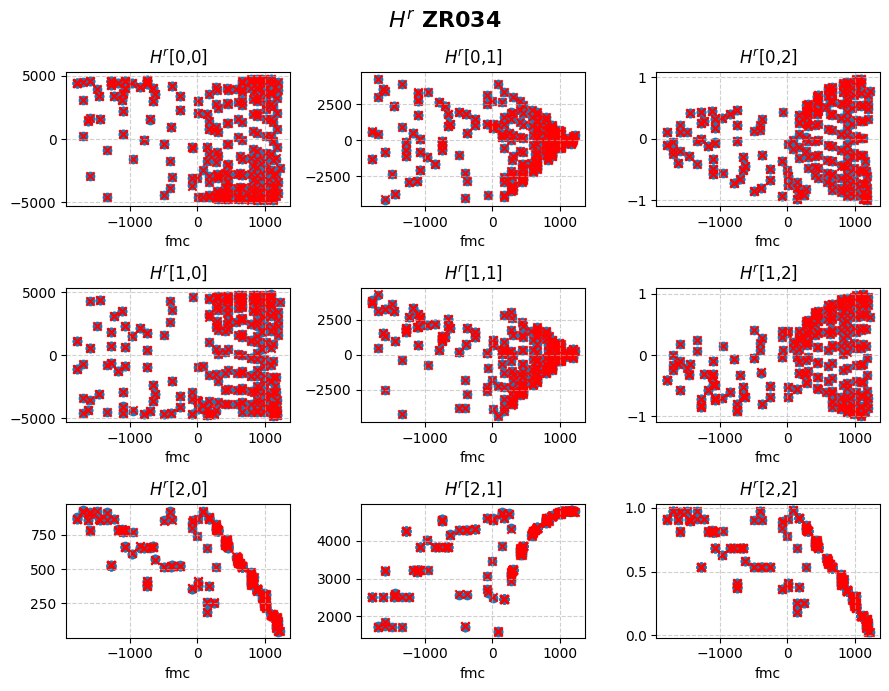

In [15]:
def plot_qmc_hr(data_, q_rrp, q_mc_0, q_mc_1, fl0, fl1):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_data_left, hr_model_left = [], []


  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ Hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ {data_['cam'].iloc[0]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

fig, ax = plot_qmc_hr(zl34, q_rrp=q_rrp, q_mc_0=q_mc_zl_0, q_mc_1=q_mc_zl_1,
    fl0=params["ZL034"]["fl0"], fl1=params["ZL034"]["fl1"])

fig, ax = plot_qmc_hr(zr34, q_rrp=q_rrp, q_mc_0=q_mc_zr_0, q_mc_1=q_mc_zr_1,
    fl0=params["ZR034"]["fl0"], fl1=params["ZR034"]["fl1"])

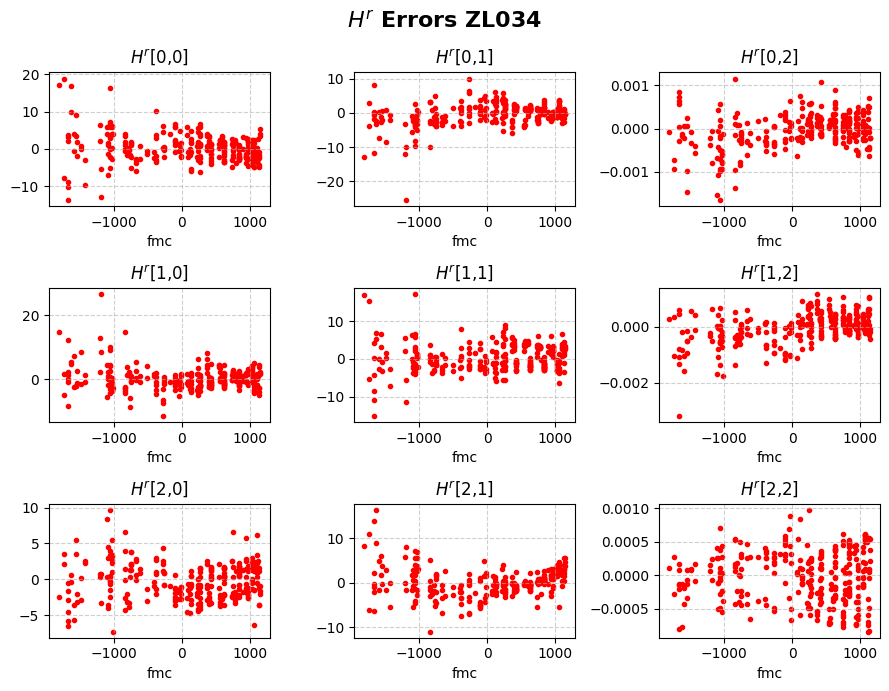

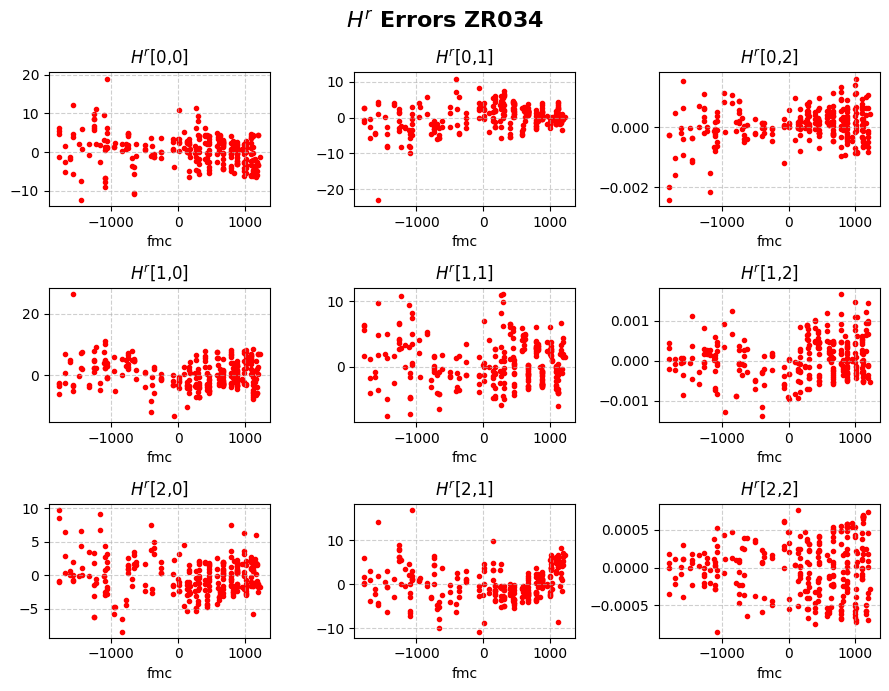

In [17]:
def plot_qmc_hr_err(data_, q_rrp, q_mc_0, q_mc_1, fl0, fl1):
  rot_mc_0 = R.from_quat(q_mc_0)
  rot_mc_1 = R.from_quat(q_mc_1)
  R_rrp = R.from_quat(q_rrp).as_matrix()

  hr_err = []


  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    f, b1, b2, cx, cy = data_[["fmc", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    cam = data_["cam"].iloc[i]
    fl = fl0 + fl1 * f
    Hc = [[fl+b1, 0, 0], [b2, fl, 0], [cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)

    f = data_["fmc"][i]
    rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
    R_mc = rot_mc.as_matrix()

    Hr_model = R_rrp @ R_rpm @ R_mc @ Hc

    hr_err.append(Hr_data - Hr_model)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_err], 
                      marker=".", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ Errors {data_['cam'].iloc[0]}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax


fig, ax = plot_qmc_hr_err(zl34, q_rrp=q_rrp, q_mc_0=q_mc_zl_0, q_mc_1=q_mc_zl_1,
    fl0=params["ZL034"]["fl0"], fl1=params["ZL034"]["fl1"])

fig, ax = plot_qmc_hr_err(zr34, q_rrp=q_rrp, q_mc_0=q_mc_zr_0, q_mc_1=q_mc_zr_1,
    fl0=params["ZR034"]["fl0"], fl1=params["ZR034"]["fl1"])